### Conversion

Convert, process, and export processed original data to a more structured and useful format (pandas DataFrame).

In [1]:
import importlib
import processing.conversion

importlib.reload(processing.conversion)

from processing.conversion import Conversion

c = Conversion(prefix='processing')

c.cleanup_data() # cleans the data directory and prepares for processing
c.process_subjects(replace=False) # processes each subject and exports to txt files

Skipping periklis as raw folder already exists
Skipping polemarchakis as raw folder already exists
Skipping nick as raw folder already exists
Skipping nikos as raw folder already exists
Skipping nastos-jr as raw folder already exists
Skipping dim_tselios as raw folder already exists
Skipping iatroudelis as raw folder already exists
Skipping dwrotheos as raw folder already exists
Skipping malidakis as raw folder already exists
Skipping anestis as raw folder already exists
Skipping manos as raw folder already exists
Skipping leonidas as raw folder already exists
Skipping thanasis as raw folder already exists
Skipping giannatos as raw folder already exists
Skipping chris as raw folder already exists
Skipping mpardas as raw folder already exists
Skipping konstantopoulos as raw folder already exists
Skipping rafa as raw folder already exists
Skipping paliaxanis as raw folder already exists
Skipping pavlidis as raw folder already exists
Skipping kiosses as raw folder already exists
Skipping 

In [2]:
df = c.get_dataframe() # returns a pandas dataframe of the processed data
df

Loading data for periklis...
Loading data for polemarchakis...
Loading data for nick...
Loading data for nikos...
Loading data for nastos-jr...
Loading data for dim_tselios...
Loading data for iatroudelis...
Loading data for dwrotheos...
Loading data for malidakis...
Loading data for anestis...
Loading data for manos...
Loading data for leonidas...
Loading data for thanasis...
Loading data for giannatos...
Loading data for chris...
Loading data for mpardas...
Loading data for konstantopoulos...
Loading data for rafa...
Loading data for paliaxanis...
Loading data for pavlidis...
Loading data for kiosses...
Loading data for mavrokefalidis...
Loading data for romas...
Loading data for nastos-sr...


,subject,mvc_level,trial_number,neuron_data,force_data
0,periklis,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, 0.012200930784608..."
1,periklis,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.006100465392304244, 0.0, -0.01830..."
2,periklis,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.012200930784608488, -0.006100465..."
3,periklis,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.03660279235382191, -0.024401861569216..."
4,periklis,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784608488, 0.0183013961769127..."
...,...,...,...,...,...
393,nastos-sr,60,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.01830139617690918, -0.00610046539..."
394,nastos-sr,60,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784608488, 0.0061004653923006..."
395,nastos-sr,60,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392300691, -0.00610046539230..."
396,nastos-sr,100,1,None,"[0.0, -0.006100465392300691, 0.0, 0.0, 0.0, -0..."


### Sanitization

Remove or correct any errors in the data. This includes removing outliers, filling in missing values, and correcting any other errors in the data. Some entries are not recoverable and will be "purged".

More information and specific algorithm implementations can be found [here](https://github.com/paul-bokelman/force-prediction/issues/3).

In [3]:
import importlib
import processing.sanitization
import processing.constants

importlib.reload(processing.sanitization)
importlib.reload(processing.constants)

from processing.sanitization import Sanitization

sanitizer = Sanitization(df=df)
sanitizer.manually_purge(processing.constants.manually_purged_trials)
df = sanitizer.sanitize(export=False)

Purging entries with insufficient neuron data...
Purged 88 entries with insufficient neuron data. 310 entries remaining.
Computing global statistics...
	Average max activation distance: 4882.267741935484
	Max force data length: 101515
	Max number of neurons: 33
	Max number of activations: 101515
Global statistics computed.
Attempting to manually purge 27 trials...
Purged [nastos-jr.10.2]
Purged [nastos-jr.10.3]
Purged [nikos.60.2]
Purged [nikos.60.3]
Purged [dim_tselios.20.1]
Purged [dim_tselios.20.3]
Purged [dim_tselios.60.1]
Purged [iatroudelis.5.3]
Purged [iatroudelis.10.3]
Purged [dwrotheos.60.3]
Purged [anestis.40.3]
Purged [manos.10.1]
Purged [leonidas.5.1]
Purged [leonidas.5.2]
Purged [leonidas.5.3]
Purged [leonidas.10.1]
Purged [leonidas.10.2]
Purged [leonidas.20.3]
Purged [thanasis.40.1]
Purged [giannatos.40.2]
Purged [mpardas.5.2]
Purged [konstantopoulos.40.1]
Purged [paliaxanis.10.3]
Purged [paliaxanis.20.2]
Purged [pavlidis.60.3]
Purged [mavrokefalidis.10.2]
Purged [mavroke

/Users/paulb/Desktop/code/research/force-prediction/processing/sanitization.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df.drop(trial.index, inplace=True) # drop the trial from the dataframe


Purged 3 entries with inconsistent firing distances
Handling measurement correlation...
	[periklis.5.1] Leading turn: 3.23291015625 | Trailing turn: 42.24169921875
	[periklis.5.1] Flat Region Interval (Inflection Points): (10.06884765625, 41.31884765625)
	[periklis.5.2] Leading turn: 9.9990234375 | Trailing turn: 48.34375
Could not find valid inflection indices for trial 2 @ 5%
	[periklis.5.3] Both regions modified -> Skipping
	[periklis.10.1] Both regions modified -> Skipping
	[periklis.10.2] Both regions modified -> Skipping
	[periklis.10.3] Both regions modified -> Skipping
	[periklis.20.1] Both regions modified -> Skipping
	[periklis.20.2] Leading turn: 5.9755859375 | Trailing turn: 34.68212890625
	[periklis.20.2] Flat Region Interval (Inflection Points): (11.8349609375, 35.2724609375)
	[periklis.20.3] Leading turn: 2.634765625 | Trailing turn: 37.95166015625
	[periklis.20.3] Flat Region Interval (Inflection Points): (11.423828125, 32.908203125)
	[periklis.40.1] Both regions modifi

In [4]:
sanitizer.show_purged() # all entries removed during sanitization process

Number of remaining entries after sanitization: 275


,subject,mvc_level,trial_number
4,anestis,10,2
11,anestis,40,3
12,anestis,60,1
15,anestis,100,1
16,anestis,100,2
...,...,...,...
379,romas,100,1
380,romas,100,2
390,thanasis,40,1
396,thanasis,100,1


### Direct Prediction

Directly predict force given neuron data using LSTM neural networks.

In [ ]:
import processing.processing
import prediction.constants

importlib.reload(processing.processing)

model_info = prediction.constants.models['2x-bi-lstm'] # gather model specific information for training & prediction
processor = processing.processing.Processing(df, model_info) # setup processor for model

Splits: train=220, val=27, test=28
Using default model presets 


In [65]:
import prediction.dpm

importlib.reload(prediction.dpm)

dpm = prediction.dpm.DirectPredictionModel(processor=processor, overwrite=True)
training_history = dpm.optionally_train() # train model if necessary (no saves)

Model not found or overwrite flag is set. Creating a new model...
Training the model...
Training model | 1 Epochs | 16 Batch Size
  387/13942 ━━━━━━━━━━━━━━━━━━━━ 30:56 137ms/step - loss: 0.1444 - mae: 0.3061

KeyboardInterrupt: 

In [63]:
# subject_name = 'giannatos'
# mvc_level = 5
# trial_number = 2

subject_name = 'dwrotheos'
mvc_level = 20
trial_number = 2

# subject_name = 'giannatos'
# mvc_level = 60
# trial_number = 2

trial = df[(df['subject'] == subject_name) & (df['mvc_level'] == mvc_level) & (df['trial_number'] == trial_number)].iloc[0]
predicted_force = dpm.predict(trial=trial)
predicted_force = processor.postprocess_prediction(trial, predicted_force) # postprocesses the prediction
print(f"Predicted force: {predicted_force}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
Predicted force: [0. 0. 0. ... 0. 0. 0.]


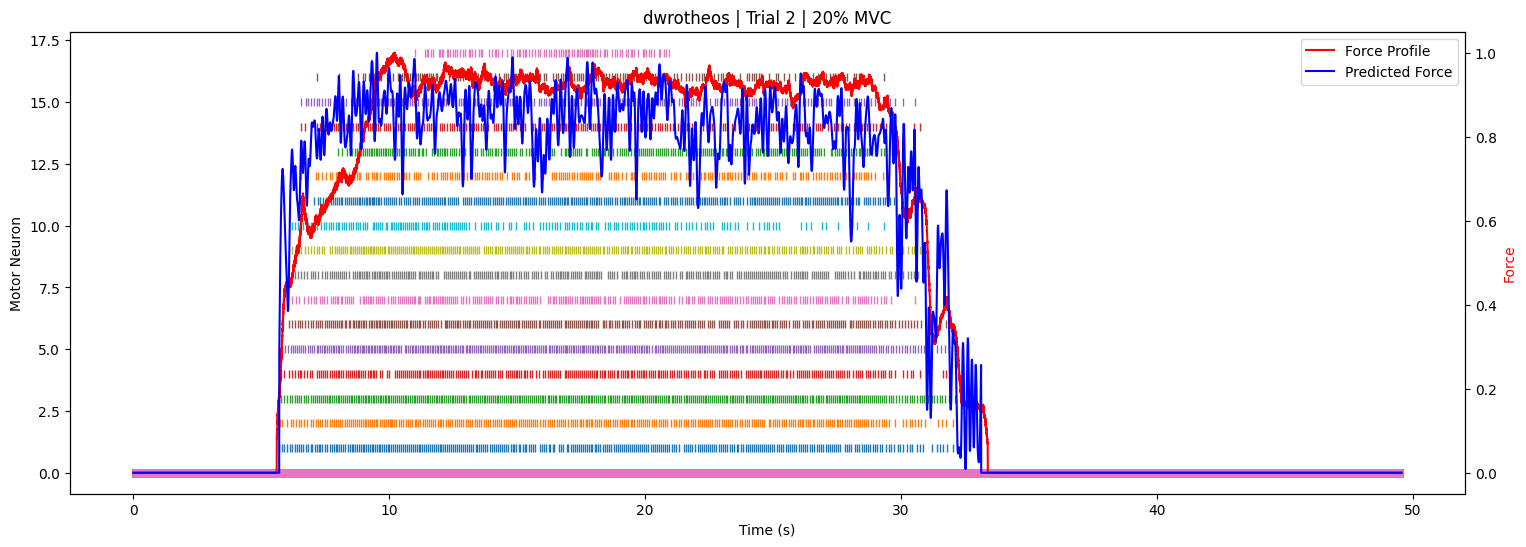

In [64]:
from globals.visualization import visualize_trial

visualize_trial(df, subject=subject_name, mvc_level=mvc_level, trial_number=trial_number, predicted_force=predicted_force)